In [1]:
import sys
import os

In [2]:
chief_path = os.path.join(os.getcwd(), 'CHIEF')
sys.path.extend([chief_path,])

In [3]:
import os
import torch
import torch.nn as nn
from torchvision import transforms
from PIL import Image, ImageOps
from models.ctran import ctranspath
from models.CHIEF import CHIEF
import numpy as np
import matplotlib.pyplot as plt
import re
from histolab.slide import Slide
from histolab.tiler import GridTiler
import matplotlib as mpl
from histolab.masks import TissueMask, BiggestTissueBoxMask

### Extracting the Tiles from base image

In [4]:
test_images = sorted(os.listdir("./test_images"))
test_images

['ck_PTGC_2x.jpeg',
 'ck_PTGC_5x.jpeg',
 'ck_SSA colon_10x.jpg',
 'ck_serositis_4x.jpg',
 'ck_steatohepatitis_100x.jpg',
 'ck_steatohepatitis_200x.jpg']

In [5]:
test_image = test_images[0]
test_image_name = test_image.split(".")[0]  # remove file extension

### Adding Padding to the images Right and bottom to make them divisible by 224

In [6]:
BASE_PATH = os.getcwd()

PATH_TEST_IMAGE = os.path.join(BASE_PATH, 'test_images', test_image)

In [7]:
test_image_pil = Image.open(PATH_TEST_IMAGE)
width, height = test_image_pil.size
print(f"Image size: {test_image_pil.size}")

Image size: (1920, 881)


In [8]:
# Calculating new width and height to make them divisible by 224
new_width = (224*int(width/224)) + 224 + 2
new_height = (224*int(height/224)) + 224 + 2
new_size = (new_width, new_height)
orig_size = test_image_pil.size

#Create new image
result = Image.new(test_image_pil.mode, (new_width, new_height), (255, 255, 255))

# Create the box to paste the old image in the center of the new image
box = tuple((n - o) // 2 for n, o in zip(new_size, orig_size))

#Place old image on the new image (left, upper, right, lower)
result.paste(test_image_pil, box)

result.save(os.path.join(BASE_PATH, 'test_images_padded', f"{test_image_name}.png"))

### Reading the padded image now

In [9]:
BASE_PATH = os.getcwd()

PATH_TEST_IMAGE_PADDED = os.path.join(BASE_PATH, 'test_images_padded', f"{test_image_name}.png")
PROCESS_PATH_TEST_IMAGE = os.path.join(BASE_PATH, 'test_images_tiles', test_image_name)

test_image_slide = Slide(PATH_TEST_IMAGE_PADDED, processed_path=PROCESS_PATH_TEST_IMAGE)

In [10]:
print(f"Slide name: {test_image_slide.name}")
print(f"Levels: {test_image_slide.levels}")
print(f"Dimensions at level 0: {test_image_slide.dimensions}")

Slide name: ck_PTGC_2x
Levels: [0]
Dimensions at level 0: (2018, 898)


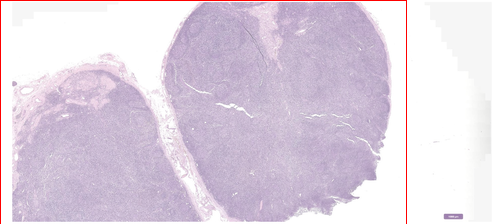

In [11]:
big_tissue_mask = BiggestTissueBoxMask()
test_image_slide.locate_mask(big_tissue_mask, scale_factor=4, tissue_mask=False, alpha=128, outline='red')

In [12]:
grid_tiles_extractor = GridTiler(
   tile_size=(224, 224),
   level=0,
   check_tissue=True, # default
   tissue_percent=0.0, # default
   pixel_overlap=0, # default
   suffix=".png" # default
)

grid_slide_image = grid_tiles_extractor.locate_tiles(
    slide=test_image_slide,
    scale_factor=2,
    alpha=128,
    outline="red",
    linewidth=2
)

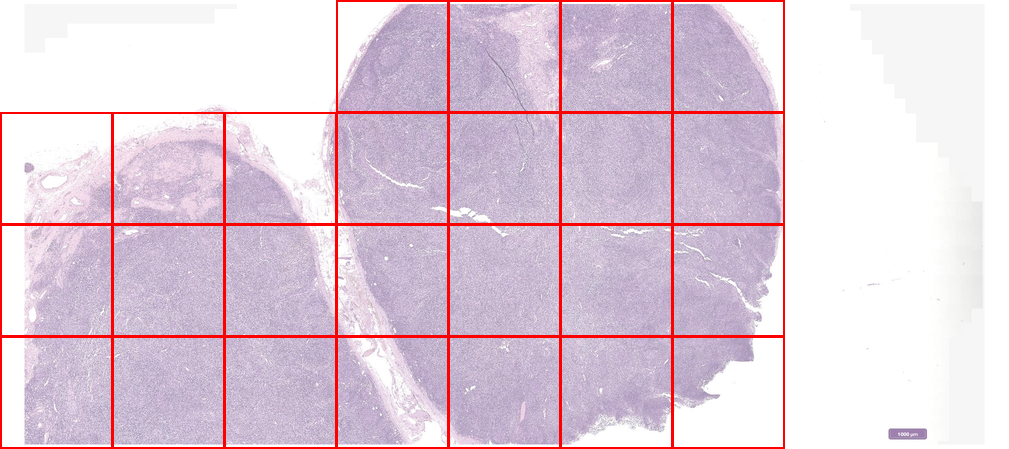

In [13]:
grid_slide_image

In [14]:
grid_slide_image.size

(1009, 449)

In [15]:
grid_slide_image.save(PROCESS_PATH_TEST_IMAGE + "_tiled.png")

In [16]:
# test_slide_image

Extract the tiles into folder. Uncomment when necessary

In [17]:
grid_tiles_extractor.extract(test_image_slide)

### Extracting tile-level features using CTransPath

In [18]:
mean = (0.485, 0.456, 0.406)
std = (0.229, 0.224, 0.225)
trnsfrms_val = transforms.Compose(
    [
        transforms.Resize(224),
        transforms.ToTensor(),
        transforms.Normalize(mean = mean, std = std)
    ]
)

In [19]:
ctranspath_model = ctranspath()
ctranspath_model.head = nn.Identity()
td = torch.load(r'./CHIEF/model_weight/CHIEF_CTransPath.pth')
ctranspath_model.load_state_dict(td['model'], strict=True)
ctranspath_model.eval()

/data/mn27889/miniconda3/envs/path-agents/lib/python3.10/site-packages/torch/functional.py:554: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at /pytorch/aten/src/ATen/native/TensorShape.cpp:4314.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


SwinTransformer(
  (patch_embed): ConvStem(
    (proj): Sequential(
      (0): Conv2d(3, 12, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(12, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): Conv2d(12, 24, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (4): BatchNorm2d(24, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (5): ReLU(inplace=True)
      (6): Conv2d(24, 96, kernel_size=(1, 1), stride=(1, 1))
    )
    (norm): LayerNorm((96,), eps=1e-05, elementwise_affine=True)
  )
  (pos_drop): Dropout(p=0.0, inplace=False)
  (layers): Sequential(
    (0): BasicLayer(
      dim=96, input_resolution=(56, 56), depth=2
      (blocks): ModuleList(
        (0): SwinTransformerBlock(
          (norm1): LayerNorm((96,), eps=1e-05, elementwise_affine=True)
          (attn): WindowAttention(
            (qkv): Linear(in_features=96, out_features=288, bias=True

In [20]:
tile_names = sorted(os.listdir(PROCESS_PATH_TEST_IMAGE), key=lambda x: int(re.search(r'(tile_)(\d+)(.*)', x).group(2)))
print('Total Tiles:', len(tile_names))

Total Tiles: 25


In [21]:
tile_tensors = []

for tile in tile_names:
    tile_path = os.path.join(PROCESS_PATH_TEST_IMAGE, tile)
    tile_orig = Image.open(tile_path).convert('RGB')
    tile_transform = trnsfrms_val(tile_orig).unsqueeze(dim=0)
    tile_tensors.append(tile_transform)

tile_tensors = torch.cat(tile_tensors, dim=0)
print('Tile Tensors:', tile_tensors.shape)

Tile Tensors: torch.Size([25, 3, 224, 224])


Extracting the tile features and saving them in the folder. Uncomment when necessary

In [22]:
with torch.no_grad():
    tiles_feature_emb = ctranspath_model(tile_tensors) # Extracted features (torch.Tensor) with shape [1,768]
    print(tiles_feature_emb.size())

torch.save(tiles_feature_emb, os.path.join(BASE_PATH, 'test_images_tiles', test_image_name + '.pt'))

torch.Size([25, 768])


### Extracting attention scores of each tile using CHIEF Model

In [23]:
chief_model = CHIEF(size_arg="small", dropout=True, n_classes=2)

td = torch.load(r'./CHIEF/model_weight/CHIEF_pretraining.pth')
chief_model.load_state_dict(td, strict=True)
chief_model.eval()

[768, 512, 256]


CHIEF(
  (attention_net): Sequential(
    (0): Linear(in_features=768, out_features=512, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.25, inplace=False)
    (3): Attn_Net_Gated(
      (attention_a): Sequential(
        (0): Linear(in_features=512, out_features=256, bias=True)
        (1): Tanh()
        (2): Dropout(p=0.25, inplace=False)
      )
      (attention_b): Sequential(
        (0): Linear(in_features=512, out_features=256, bias=True)
        (1): Sigmoid()
        (2): Dropout(p=0.25, inplace=False)
      )
      (attention_c): Linear(in_features=256, out_features=1, bias=True)
    )
  )
  (classifiers): Linear(in_features=512, out_features=2, bias=True)
  (instance_classifiers): ModuleList(
    (0-1): 2 x Linear(in_features=512, out_features=2, bias=True)
  )
  (instance_loss_fn): CrossEntropyLoss()
  (att_head): Att_Head(
    (fc1): Linear(in_features=512, out_features=256, bias=True)
    (relu): ReLU()
    (fc2): Linear(in_features=256, out_features=1, bias=True)
    (s

In [24]:
feature_path = os.path.join(BASE_PATH, 'test_images_tiles', test_image_name + '.pt')

tiles_feature_emb = torch.load(feature_path, map_location=torch.device('cpu'))
print('Patch Feature Embedding Shape:', tiles_feature_emb.shape)

Patch Feature Embedding Shape: torch.Size([25, 768])


In [25]:
anatomical=13
with torch.no_grad():
    x,tmp_z = tiles_feature_emb,anatomical
    result = chief_model(x, torch.tensor([tmp_z]))
    wsi_feature_emb = result['WSI_feature']  ###[1,768]
    raw_attention = result['attention_raw'].squeeze().cpu().numpy()
    raw_attention_softmax = torch.nn.functional.softmax(result['attention_raw'], dim=1).squeeze().cpu().numpy()
    print('WSI Feature Size', wsi_feature_emb.shape)
    print('Slide-Level Raw Attention Vector:', raw_attention.shape)
    print('Slide-Level Raw Attention Vector (Softmax):', raw_attention_softmax.shape)

WSI Feature Size torch.Size([1, 768])
Slide-Level Raw Attention Vector: (25,)
Slide-Level Raw Attention Vector (Softmax): (25,)


Making attention scores all positive values and adding an offset of 1. This will ensure that non-selected tiles have a value of 0

In [26]:
raw_attention = raw_attention + abs(np.min(raw_attention)) + 1

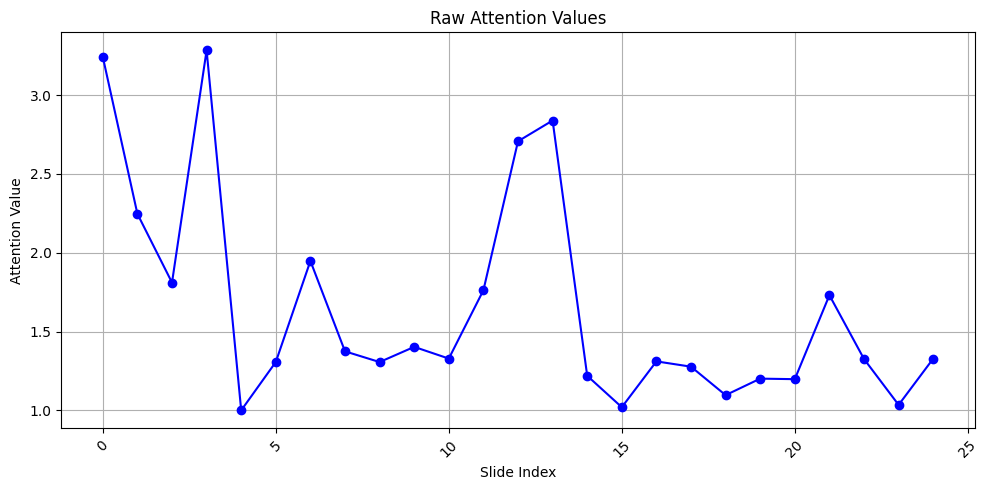

In [27]:
x_data = list(range(0,len(raw_attention)))
y_data = raw_attention.tolist()

plt.figure(figsize=(10, 5))
plt.plot(x_data, y_data, marker='o', linestyle='-', color='b')
plt.title('Raw Attention Values')
plt.xlabel('Slide Index')
plt.ylabel('Attention Value')
plt.xticks(rotation=45)
plt.grid()
plt.tight_layout()
plt.show()

### Mapping the CHIEF attention values to individual tiles

In [28]:
src_image = Image.open(PATH_TEST_IMAGE).convert('RGB')

In [29]:
src_image.size

(1920, 881)

In [30]:
x_dim, y_dim, z_dim = np.array(src_image).shape #PIL Shape has opposite dimentions of x and y when converted to numpy array
test_heatmap = np.zeros((x_dim, y_dim), dtype=float)
print('Heatmap Dimensions:', test_heatmap.shape)

Heatmap Dimensions: (881, 1920)


In [31]:
tile_dict = dict(zip(tile_names, raw_attention))
print('Dictionary Length', len(tile_dict))

Dictionary Length 25


In [32]:
for key, val in tile_dict.items():
    tile_search = re.search('tile_(\d+)_level(\d+)_(\d+)-(\d+)-(\d+)-(\d+).png', key)
    if tile_search:
        x_ul_wsi = int(tile_search.group(3))
        y_ul_wsi = int(tile_search.group(4))
        x_br_wsi = int(tile_search.group(5))
        y_br_wsi = int(tile_search.group(6))
        test_heatmap[y_ul_wsi:y_br_wsi, x_ul_wsi:x_br_wsi] = val

### Drawing Image and Heatmap side by side

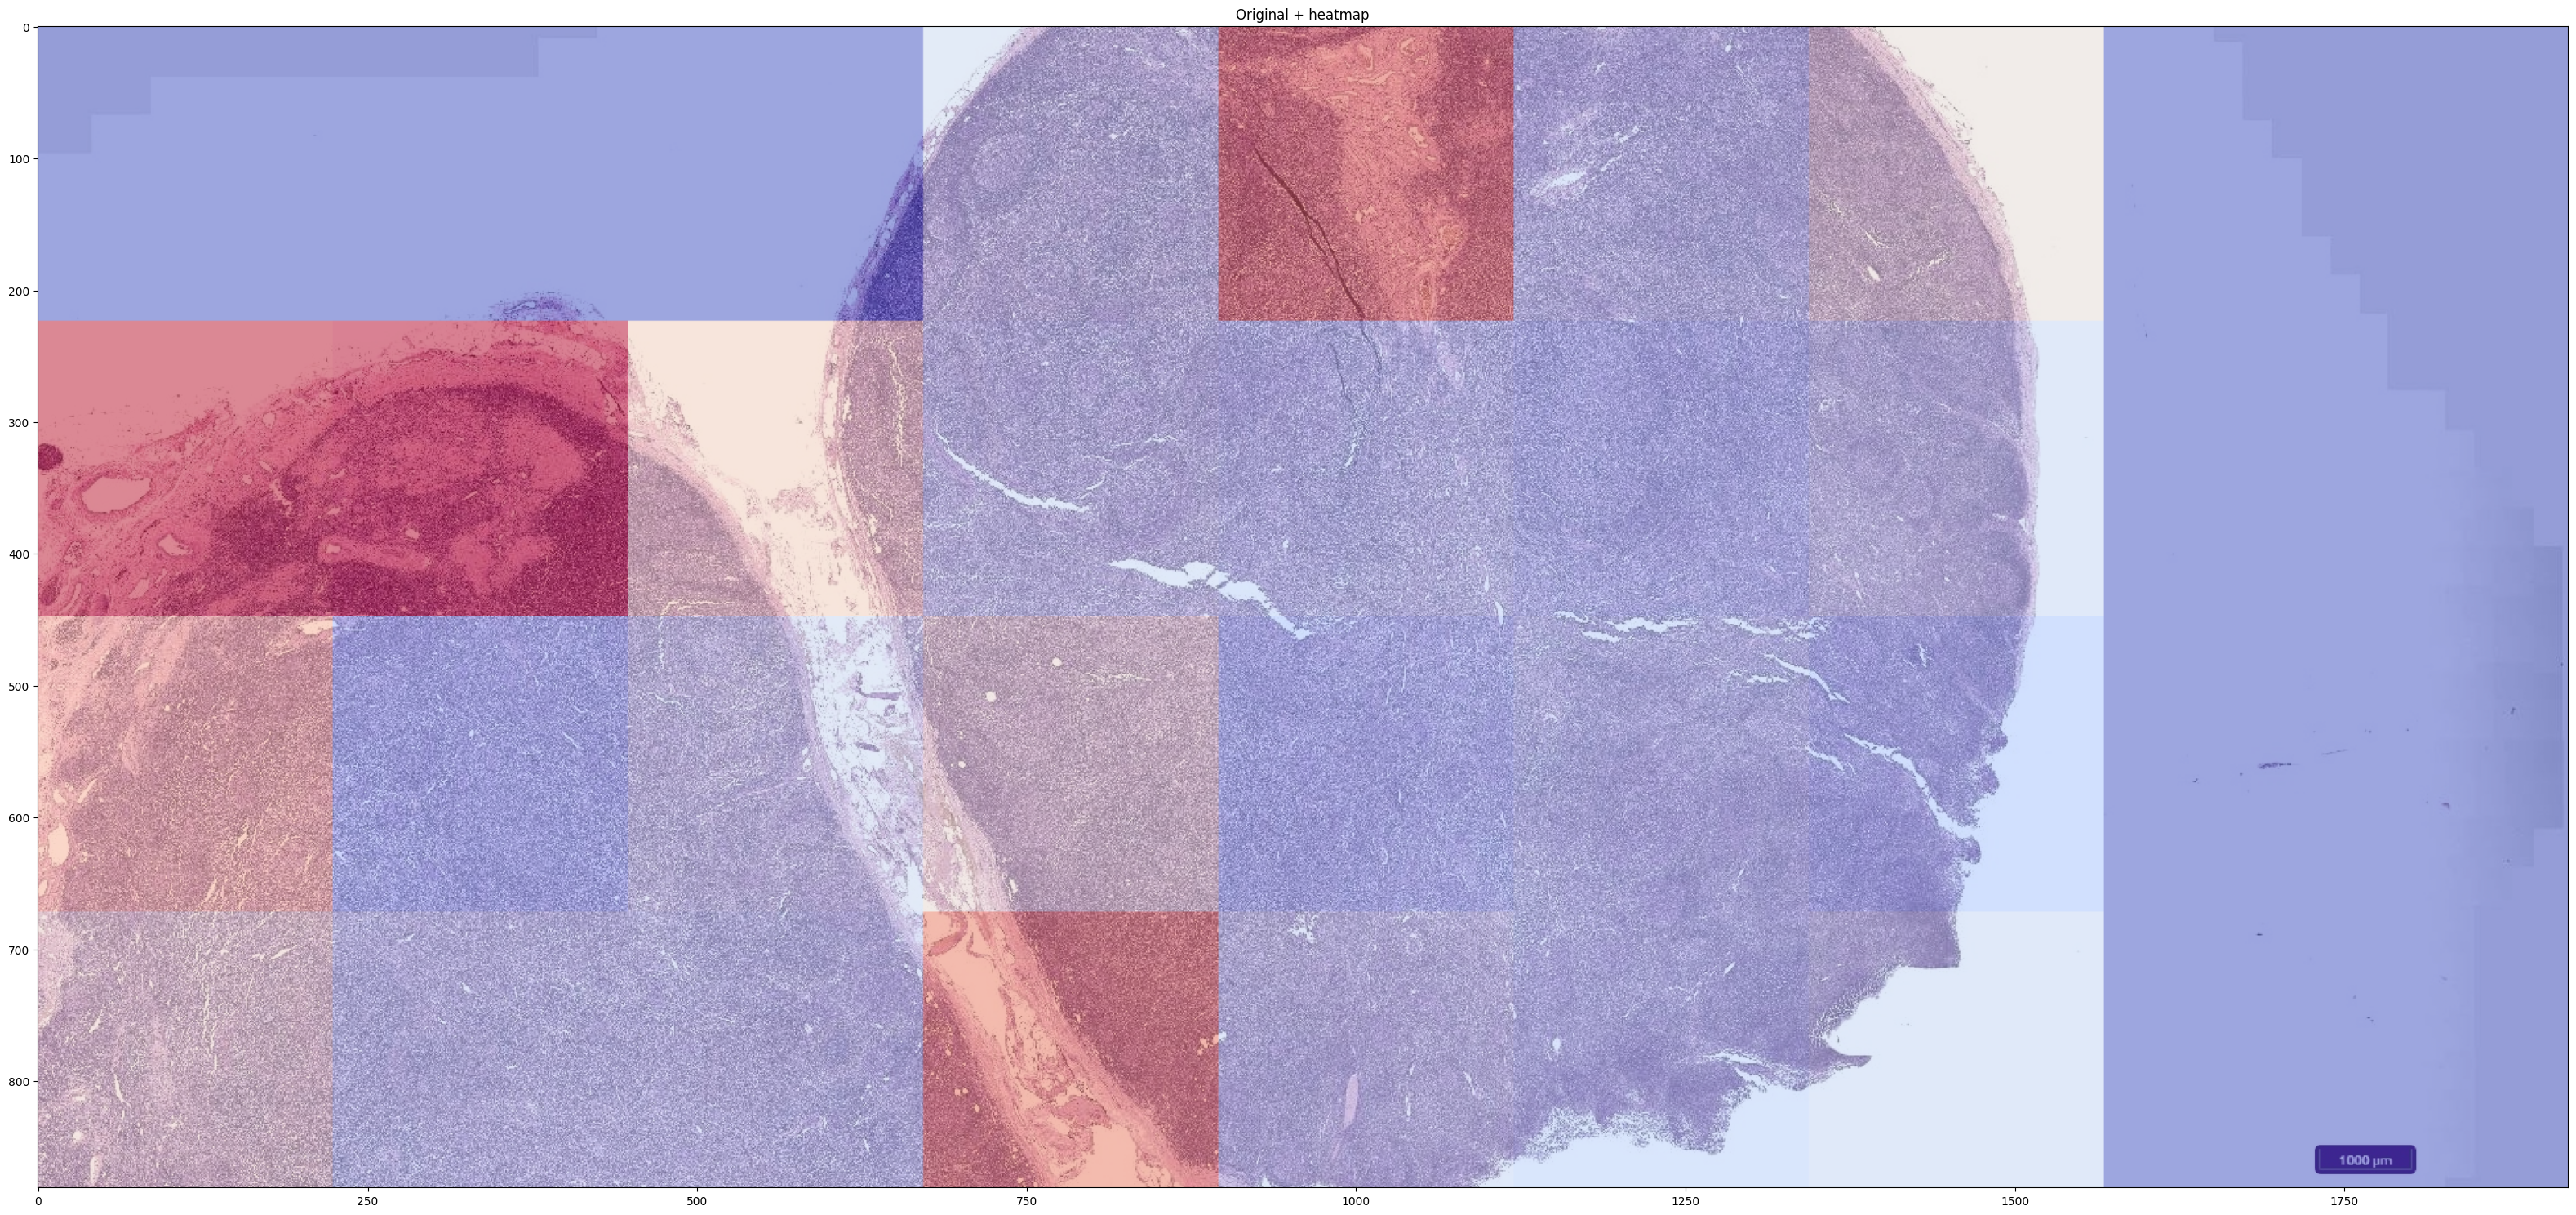

In [33]:
plt.figure(figsize=(40, 20))

plt.imshow(src_image, vmin=0, vmax=1)
plt.imshow(test_heatmap, alpha=0.5, cmap='coolwarm', interpolation='bilinear')
plt.title("Original + heatmap")
plt.savefig(PROCESS_PATH_TEST_IMAGE + "_heatmap.png")
# plt.show()

In [34]:
# fig, axes = plt.subplots(2,1, figsize=(40, 20), sharex=True, sharey=True)
# ax = axes.ravel()
# ax[0].imshow(src_image, cmap='coolwarm')
# ax[0].set_title("Original")
# fig.colorbar(ax[0].imshow(src_image), ax=ax[0], fraction=0.046, pad=0.04)

# ax[1].imshow(src_image, vmin=0, vmax=1)
# ax[1].imshow(test_heatmap, alpha=0.5, cmap='coolwarm', interpolation='bilinear')
# ax[1].set_title("Original + heatmap")

# # Specific colorbar
# norm = mpl.colors.Normalize(vmin=0,vmax=1)
# N = 11
# cmap = plt.get_cmap('coolwarm',N)
# sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
# sm.set_array([])
# plt.colorbar(sm, ax=ax[1], ticks=np.linspace(0,1,N), boundaries=np.arange(0,1.1,0.1), fraction=0.046, pad=0.04) 

# fig.tight_layout()
# plt.show()